In [218]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr
from scipy.stats import norm
import seaborn as sns

#select particular representative gauge
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    mask_size = '892'
    list_size = ['225','529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    mask_size = '961'
    list_size = ['228','550','961','1773','3669','6941']

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"


In [ ]:
test_set= 3
event_id = 7000
site = 9
for train_size in list_size:
    sample = np.load(f'{MLDir}/model/{reg}/sigmaMC/out/mc_samples_trainsize{train_size}_testsize{test_set}_direct.npy')
    tpe_table = pd.read_csv(f'{MLDir}/model/{reg}/sigmaMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_testsize{test_set}.csv')
    print(sample.shape)
    print(tpe_table.shape)
    pt_sc_sample = sample[:,event_id,site-1]
    tpe_sc = tpe_table.iloc[[event_id]]
    
    #plot data
    plt.hist(pt_sc_sample,bins=25,density=True)
    plt.axvline(np.mean(pt_sc_sample),color='r',label='MC mean,sigma ')
    plt.axvline(np.mean(pt_sc_sample)+np.std(pt_sc_sample),color='r',linestyle='--')
    plt.axvline(np.mean(pt_sc_sample)-np.std(pt_sc_sample),color='r',linestyle='--')
    bias = np.abs(tpe_sc[f'T{site}'].values-np.mean(pt_sc_sample))[0]
    var = np.var(pt_sc_sample)
    plt.text(
        0.5, 
        -0.2, 
        f"Size {train_size}, Bias {bias:.3f}, Variance {var:.3f}",
        fontsize=20, 
        ha="center", 
        va="bottom", 
        transform=plt.gca().transAxes
    )
    
    #from stats of the normal model
    plt.axvline(tpe_sc[f'T{site}'].values,color='g',label='True value')
    plt.xlabel('Sample depths')
    plt.ylabel('Density')
    plt.title('Histogram of MC dropout samples')
    plt.legend()
    plt.show()

Plot variance reduction at different training sizes

1
2.4456497292828046e-06 2.069926508167024e-06 1.2900486640170299e-06 (-1.8002194838840658e-06, 5.940072500218114e-06)
2
8.375779829530438e-05 0.0001111306881389 2.7095221005244186e-05 (2.9845025123167445e-05, 0.00019241635115463255)
3
9.213575713941164e-07 1.197588276281747e-06 5.18280740289145e-07 (-3.5725394458568767e-07, 2.752430497149182e-06)
4
5.316615684514291e-06 6.006792975436963e-06 5.558442377403134e-06 (-1.0668534156772438e-05, 2.2682120107646367e-05)


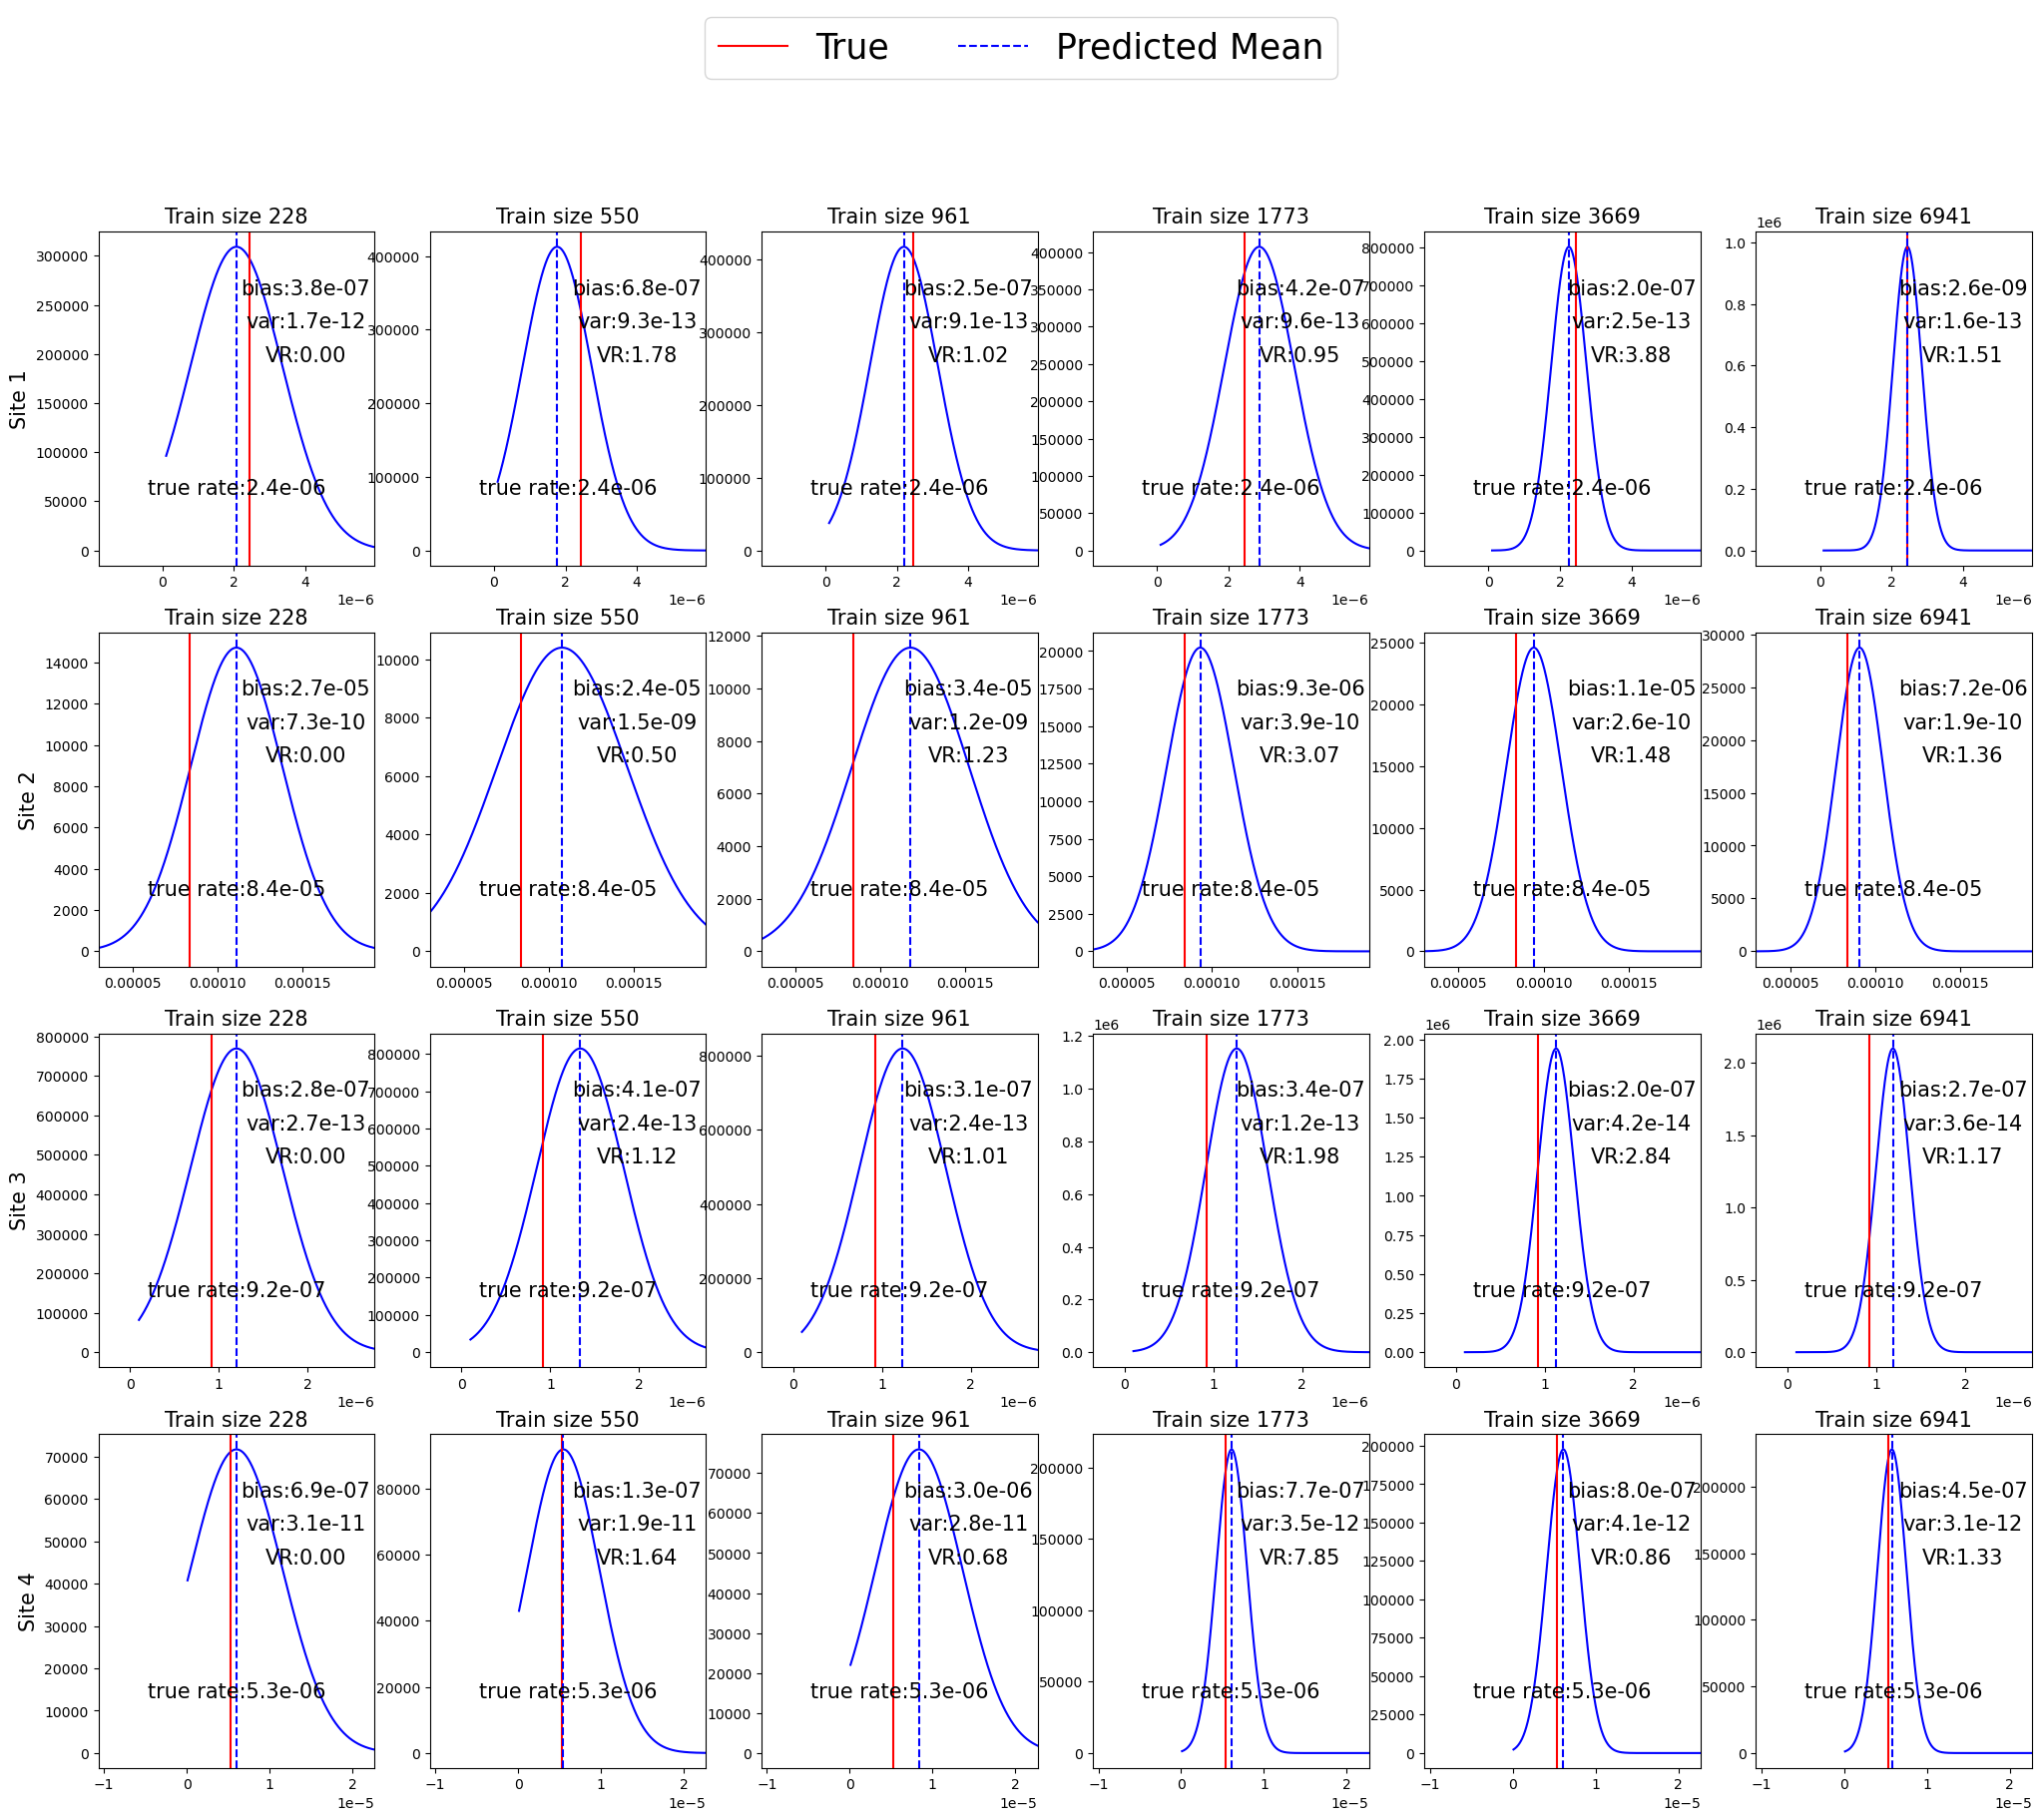

In [222]:
fig, ax = plt.subplots(4, 6, figsize=(25, 20))
for Site in range(1, 5):
    print(Site)
    j = Site - 1
    Table_rate = pd.read_csv(f'rate_error_table_{reg}_allsites.csv')
    # Table_depth= pd.read_csv('depth_error_table_SR_allsites.csv')
    Table_rate = Table_rate[Table_rate['Site'] == Site]
    # Table_rate = Table_rate[Table_rate['Depth'] == Depth]
    prev_var = 0
    for i, train_size in enumerate(list_size): 
        # plot normal models with true, pred and variance at different 6 sizes
        obs = Table_rate[Table_rate['Train_size'] == int(train_size)]['True'].item()  # True
        mu = Table_rate[Table_rate['Train_size'] == int(train_size)]['Pred'].item()  # Mean
        sigma = Table_rate[Table_rate['Train_size'] == int(train_size)]['Sigma'].item()/2  # Standard deviation fron 2 sigma
        
        #set limits for x axis
        if i == 0:
            # print(mu, sigma)
            limits = mu - 3*sigma, mu + 3*sigma
            print(obs, mu, sigma, limits)
        
        # fit a normal distribution
        x = np.logspace(-7, -3, 10000)
        ax[j, i].plot(x, norm.pdf(x, mu, sigma), color='b')
        ax[j, i].axvline(obs, color='r', label='True')
        ax[j, i].axvline(mu, color='b', label='Predicted Mean', linestyle='--')
        # ax[j, i].axvline(mu + 2*sigma, color='g', label='Predicted Mean+Sigma', linestyle='--')
        # ax[j, i].axvline(mu - 2*sigma, color='g', label='Predicted Mean-Sigma', linestyle='--')
        # print variance, bias

        var = sigma**2
        if i == 0:
            VR = 0
        else:
            VR = prev_var / var
        prev_var = var
        ax[j, i].text(0.5, 0.2, f"true rate:{obs:.1e}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].text(0.75, 0.8, f"bias:{np.abs(obs - mu):.1e}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].text(0.75, 0.7, f"var:{var:.1e}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].text(0.75, 0.6, f"VR:{VR:.2f}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].set_title(f"Train size {train_size}",fontsize=15)
        ax[j, i].set_xlim(limits[0], limits[1])
        # ax[j, i].set_xscale('log')


        # row label as site no
        if i == 0 or i == 6 or i == 12 or i == 18:
            ax[j, i].set_ylabel(f"Site {Site}", fontsize=15)
handle,label = ax[0,0].get_legend_handles_labels()
fig.legend(handle,label,loc='upper center',ncol=2,fontsize=25)
plt.show()


1
9.790820556949785e-06 2.5772058368048587e-05 1.9741329769500545e-05 (-3.345193094045305e-05, 8.499604767655022e-05)
2
6.9633672609836665e-06 9.153917701438238e-06 6.99743604269148e-06 (-1.18383904266362e-05, 3.0146225829512675e-05)
3
1.6397590145028309e-06 2.729753489063115e-06 1.438622308544612e-06 (-1.5861134365707215e-06, 7.045620414696951e-06)
4
1.7544427594776545e-05 1.7057058505867688e-05 1.6598384612526e-05 (-3.273809533171032e-05, 6.68522123434457e-05)


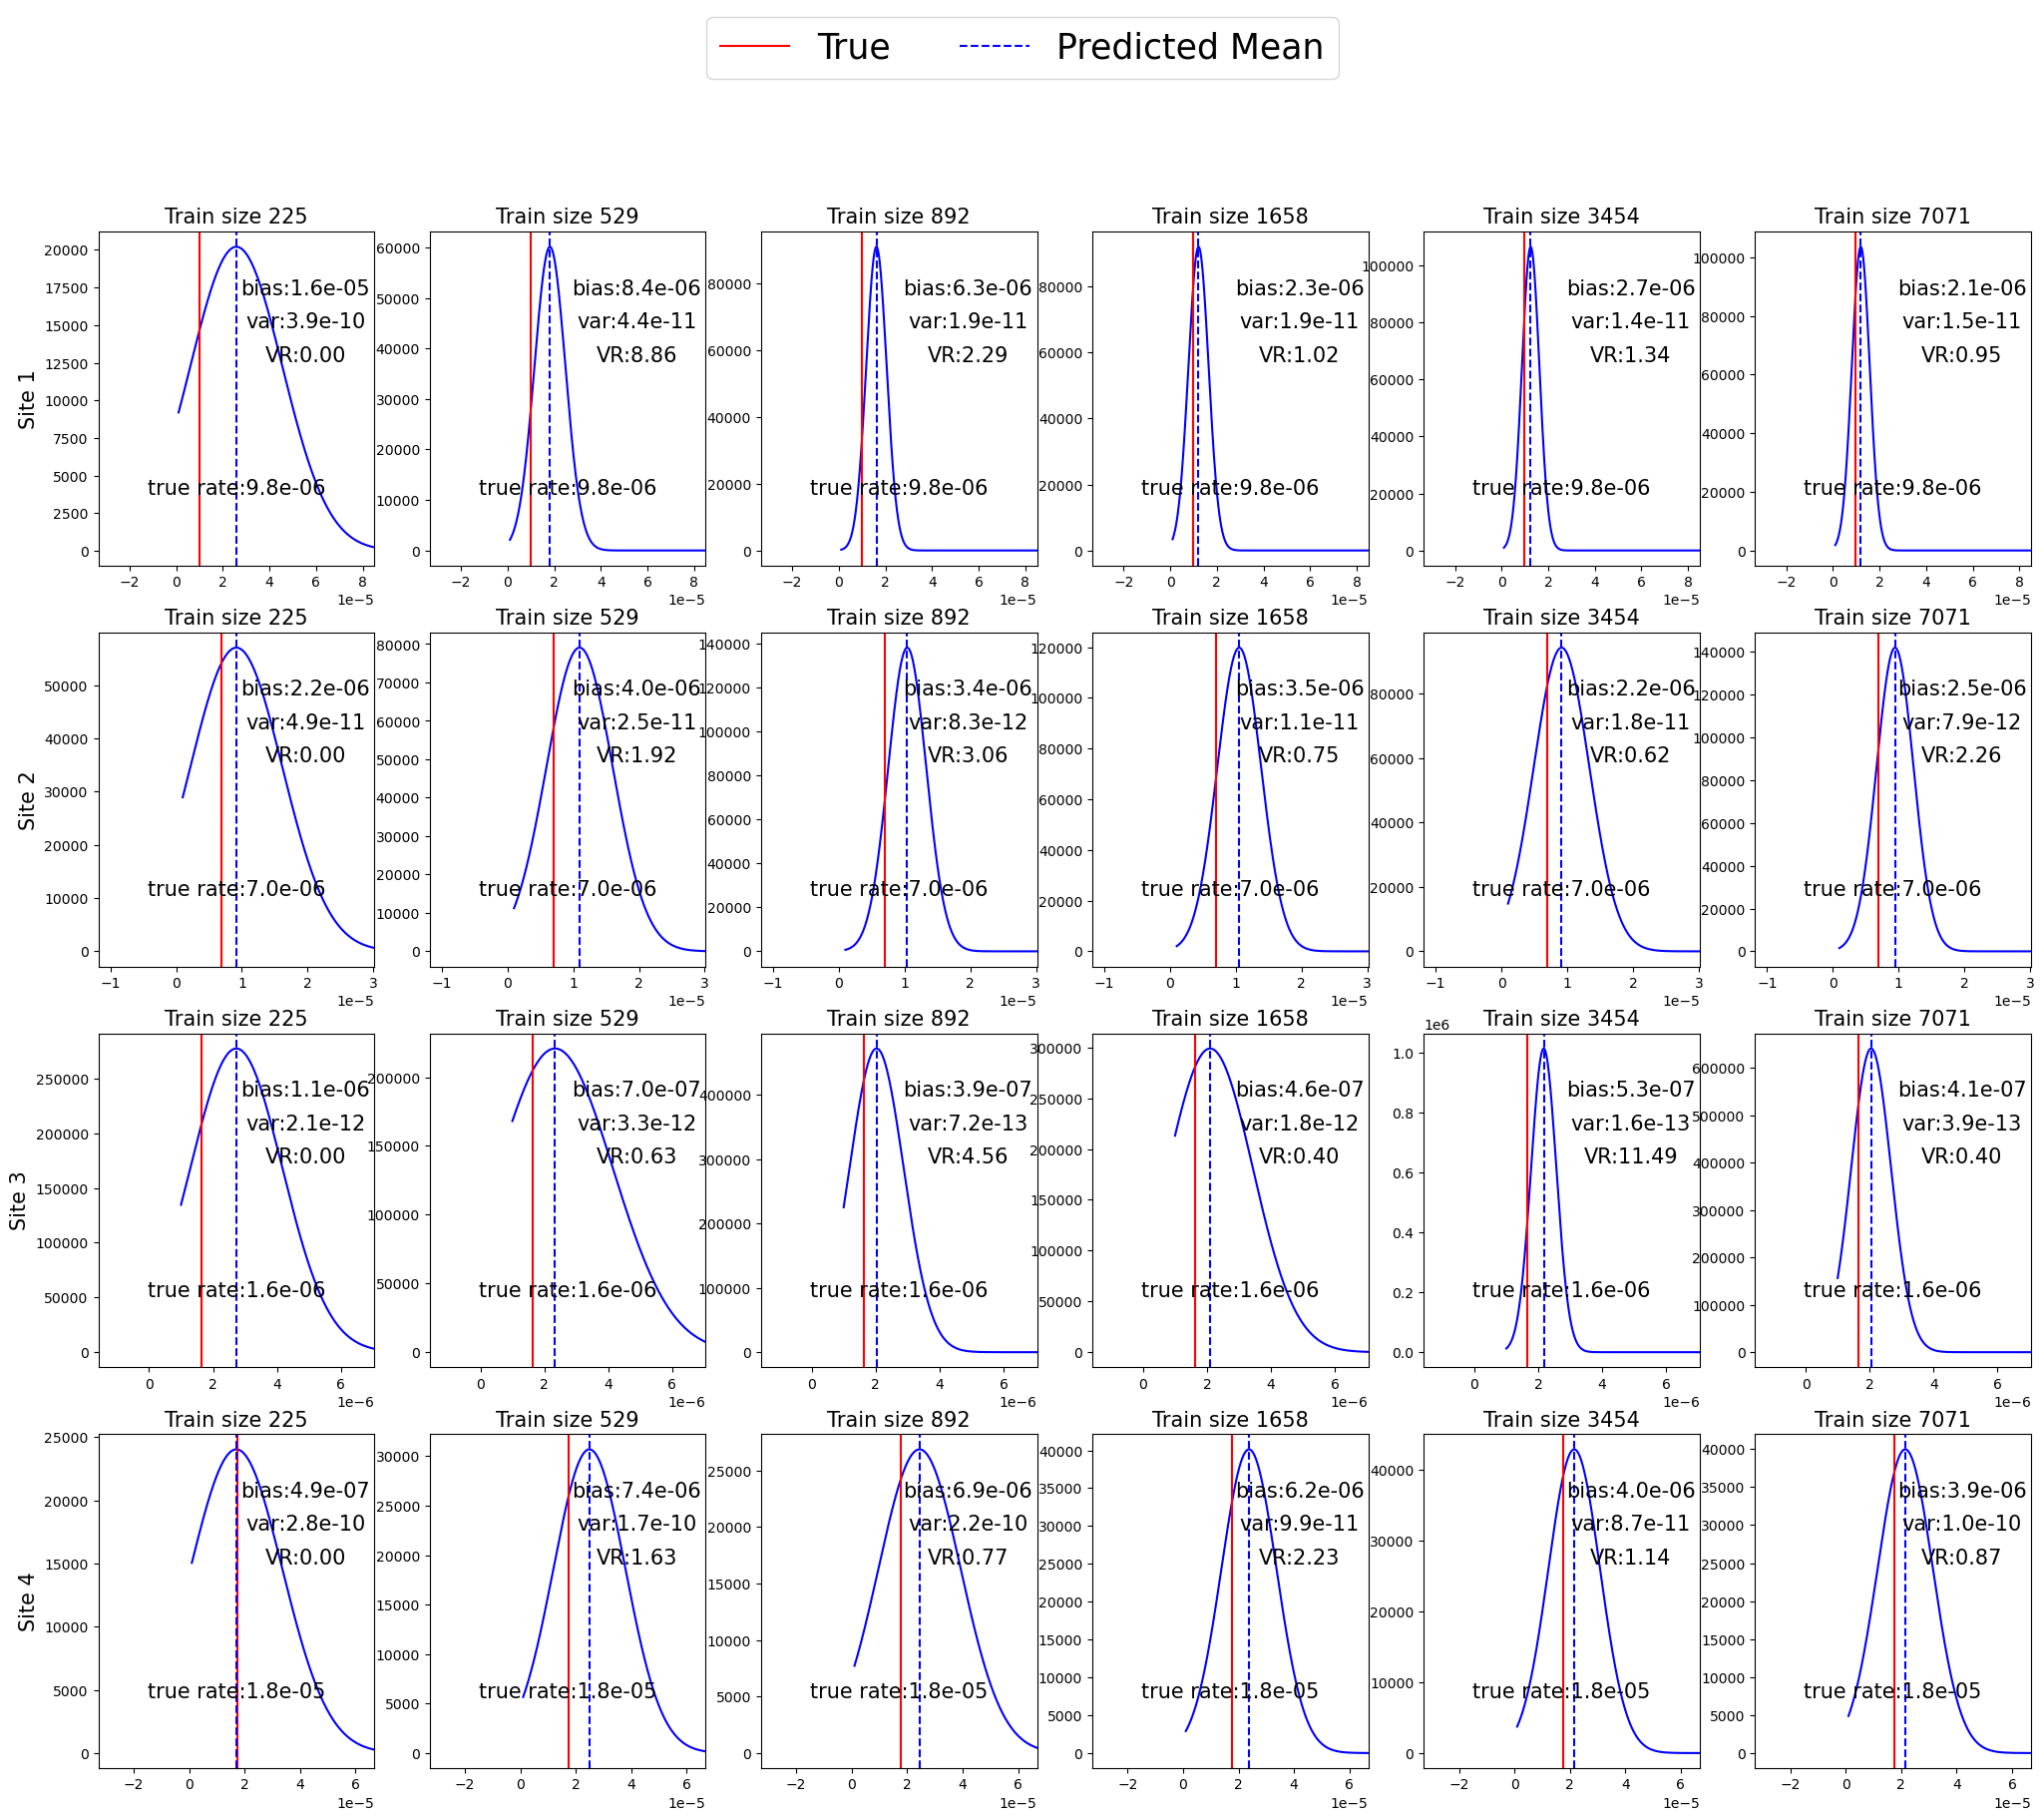

In [216]:
fig, ax = plt.subplots(4, 6, figsize=(25, 20))
for Site in range(1, 5):
    print(Site)
    j = Site - 1
    Table_rate = pd.read_csv(f'rate_error_table_{reg}_allsites.csv')
    # Table_depth= pd.read_csv('depth_error_table_SR_allsites.csv')
    Table_rate = Table_rate[Table_rate['Site'] == Site]
    # Table_rate = Table_rate[Table_rate['Depth'] == Depth]
    prev_var = 0
    for i, train_size in enumerate(list_size): 
        # plot normal models with true, pred and variance at different 6 sizes
        obs = Table_rate[Table_rate['Train_size'] == int(train_size)]['True'].item()  # True
        mu = Table_rate[Table_rate['Train_size'] == int(train_size)]['Pred'].item()  # Mean
        sigma = Table_rate[Table_rate['Train_size'] == int(train_size)]['Sigma'].item()/2  # Standard deviation fron 2 sigma
        
        #set limits for x axis
        if i == 0:
            # print(mu, sigma)
            limits = mu - 3*sigma, mu + 3*sigma
            print(obs, mu, sigma, limits)
        
        # fit a normal distribution
        x = np.logspace(-6, -4, 10000)
        ax[j, i].plot(x, norm.pdf(x, mu, sigma), color='b')
        ax[j, i].axvline(obs, color='r', label='True')
        ax[j, i].axvline(mu, color='b', label='Predicted Mean', linestyle='--')
        # ax[j, i].axvline(mu + 2*sigma, color='g', label='Predicted Mean+Sigma', linestyle='--')
        # ax[j, i].axvline(mu - 2*sigma, color='g', label='Predicted Mean-Sigma', linestyle='--')
        # print variance, bias

        var = sigma**2
        if i == 0:
            VR = 0
        else:
            VR = prev_var / var
        prev_var = var
        ax[j, i].text(0.5, 0.2, f"true rate:{obs:.1e}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].text(0.75, 0.8, f"bias:{np.abs(obs - mu):.1e}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].text(0.75, 0.7, f"var:{var:.1e}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].text(0.75, 0.6, f"VR:{VR:.2f}", fontsize=15, ha="center", va="bottom", transform=ax[j, i].transAxes)
        ax[j, i].set_title(f"Train size {train_size}",fontsize=15)
        ax[j, i].set_xlim(limits[0], limits[1])
        # ax[j, i].set_xscale('log')


        # row label as site no
        if i == 0 or i == 6 or i == 12 or i == 18:
            ax[j, i].set_ylabel(f"Site {Site}", fontsize=15)
handle,label = ax[0,0].get_legend_handles_labels()
fig.legend(handle,label,loc='upper center',ncol=2,fontsize=25)
plt.show()
